Author: Robin Sternberg  
This notebook is licensed under Creative Commons Attribution-ShareAlike 4.0

# Statistische Analyse 2 - Auszählen

In diesem Notebook werden Bundestagsprotokolle analysiert, um die Redeanteile der Parteien, den Beifall und die Zwischenrufe zu untersuchen.  
Die Analyse umfasst mehrere Bundestagsperioden. Bei Bundestagsperiodenspezifischen Plots habe ich die 20., 19., 18. und 12. Bundestagsperiode analysiert.

Zusätzlich zu diesem Notebook gibt habe ich per Gradio ein Frontend geschrieben, das ausgewählte Plots enthält.  
Dort kann man auch die anderen Bundestagsperioden auswählen und selbst die unterschiedlichen Normalisierungsarten ausprobieren.  
Die Applikation ist auf Huggingface Spaces frei verfügbar. https://huggingface.co/spaces/stellamo/bundestag_stats  
Die Gradio-App ist neben dem öffentlichen Repository auf Huggingface auch im Ordner [./gradio](./gradio/) verfügbar.

Anmerkung: Im Viewer von Gitlab werden die interaktiven Plots von plotly nicht angezeigt. Das Notebook muss deswegen in einer Jupyter-Umgebung oder einer IDE geöffnet werden.

## Daten laden

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
pd.options.mode.chained_assignment = None

In [2]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'BSW', 'fraktionslos']

In [3]:
df_interruptions = pd.read_parquet('../_data/interruptions.parquet')
df_interruptions.head()

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der Welt!,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
3,3,Gebt erst mal das Vermögen der DIE LINKE dem S...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
4,4,Die DIE LINKE soll das Vermögen zurückgeben!,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7


In [4]:
df_speeches = pd.read_parquet('../_data/speeches.parquet').set_index('speech_id')
df_speeches.head()

,speaker_party,speaker,applause,speech_len_sents,date
speech_id,,,,,
1,CDU/CSU,Dr. Theodor Waigel,"{""CDU/CSU"": 6, ""GR\u00dcNE"": 0, ""SPD"": 2, ""FDP...",386,1991-03-12
2,DIE LINKE,Dr. Barbara Höll,"{""CDU/CSU"": 0, ""GR\u00dcNE"": 0, ""SPD"": 0, ""FDP...",11,1991-03-12
3,CDU/CSU,Dr. Jürgen Rüttgers,"{""CDU/CSU"": 2, ""GR\u00dcNE"": 0, ""SPD"": 0, ""FDP...",15,1991-03-12
4,SPD,Dr. Peter Struck,"{""CDU/CSU"": 0, ""GR\u00dcNE"": 0, ""SPD"": 1, ""FDP...",4,1991-03-12
5,FDP,Dr. Wolfgang Weng,"{""CDU/CSU"": 3, ""GR\u00dcNE"": 0, ""SPD"": 2, ""FDP...",15,1991-03-12


In [5]:
def clear_title(name):
    if name.startswith('Dr.'):
        return name[4:] 
    return name
df_speeches['speaker'] = df_speeches['speaker'].apply(clear_title)
df_speeches.head()

,speaker_party,speaker,applause,speech_len_sents,date
speech_id,,,,,
1,CDU/CSU,Theodor Waigel,"{""CDU/CSU"": 6, ""GR\u00dcNE"": 0, ""SPD"": 2, ""FDP...",386,1991-03-12
2,DIE LINKE,Barbara Höll,"{""CDU/CSU"": 0, ""GR\u00dcNE"": 0, ""SPD"": 0, ""FDP...",11,1991-03-12
3,CDU/CSU,Jürgen Rüttgers,"{""CDU/CSU"": 2, ""GR\u00dcNE"": 0, ""SPD"": 0, ""FDP...",15,1991-03-12
4,SPD,Peter Struck,"{""CDU/CSU"": 0, ""GR\u00dcNE"": 0, ""SPD"": 1, ""FDP...",4,1991-03-12
5,FDP,Wolfgang Weng,"{""CDU/CSU"": 3, ""GR\u00dcNE"": 0, ""SPD"": 2, ""FDP...",15,1991-03-12


Check auf N/A-Werte 

In [6]:
rows_with_na = df_speeches[df_speeches.isna().any(axis=1)]
rows_with_na

,speaker_party,speaker,applause,speech_len_sents,date
speech_id,,,,,


In [7]:
df_speeches.columns

Index(['speaker_party', 'speaker', 'applause', 'speech_len_sents', 'date'], dtype='object')

## Redeanteile
Als erstes sehen wir nach, wann und wie viel überhaupt im Bundestag geredet wird.

In [8]:
df_speeches['year'] = df_speeches['date'].apply(lambda x: x[:4])

df_speeches_grouped = df_speeches.groupby('year')['speech_len_sents'].sum().reset_index()
df_speeches_grouped['number_protocols'] = df_speeches.groupby('year')['date'].nunique().to_list()
df_speeches_grouped.head()

,year,speech_len_sents,number_protocols
0,1991,165820,56
1,1992,177752,61
2,1993,206787,70
3,1994,157376,51
4,1995,202714,68


In [9]:
fig = px.line(df_speeches_grouped,
              x='year',
              y='speech_len_sents',
              title='Gesamtanzahl der Anzahl der Sätze im Bundestag nach Jahr',
              labels={'year': 'Jahr', 'speech_len_sents': 'Anzahl von Sätzen'},
              markers=True,)
fig.update_layout(hovermode='x unified')

Die Anzahl der Sätze scheint seit 1991 einen Aufwärts-Trend zu haben. Während in der Wahlperiode von 1994 bis 1998 das Maximum an Sätzen/Jahr bei 212 Tausend lag, ist es jetzt bei über 350 Tausend. 

Was außerdem auffällt ist, dass in den Wahljahren immer ein kleiner Knick enthalten ist. Das ist dem geschuldet, dass in den Wahljahren auch weniger Sitzungen stattfinden, damit die Abgeordneten dem Wahlkampf in ihrem Wahlkreis nachgehen können.  
Das zeigt der nächste Plot:

In [10]:
fig = px.line(df_speeches_grouped,
              x='year',
              y='number_protocols',
              title='Anzahl der Sitzungen im Bundestag nach Jahr',
              labels={'year': 'Jahr', 'number_protocols': 'Anzahl der Sitzungen'},
              markers=True,)
fig.update_layout(hovermode='x unified')

### Redeanteile nach Partei

Interessant ist aber wohl eher, wer denn jetzt eigentlich die Redezeit ausfüllt. Diese Frage wird im Folgenden Abschnitt beantwortet.

In [11]:
df_grouped_parties_years = df_speeches.groupby(['year', 'speaker_party'])['speech_len_sents'].sum().reset_index()

df_grouped_parties_years.head()

,year,speaker_party,speech_len_sents
0,1991,CDU/CSU,64155
1,1991,DIE LINKE,12773
2,1991,FDP,28035
3,1991,GRÜNE,8762
4,1991,SPD,51603


In [12]:
# put 0 for every party which is not present in a given year
for year in range(1991, 2025):
    year_str = str(year)
    for party in parties:
        if df_grouped_parties_years[(df_grouped_parties_years['year'] == year_str) & (df_grouped_parties_years['speaker_party'] == party)].empty:
            df_grouped_parties_years = pd.concat([df_grouped_parties_years, pd.DataFrame([{'year': year_str, 'speaker_party': party, 'speech_len_sents': 0}])], ignore_index=True)

df_grouped_parties_years = df_grouped_parties_years.sort_values(by='year', ascending=True)


In [13]:
party_colors = {
    'CDU/CSU': 'black',
    'AfD': 'lightblue',
    'DIE LINKE': '#bd3075',
    'BSW': '#7d254f',
    'SPD': 'red',
    'GRÜNE': 'green',
    'FDP': 'yellow',
    'fraktionslos': 'grey'
}

fig = px.line(df_grouped_parties_years,
              x='year',
              y='speech_len_sents',
              color='speaker_party',
              title='Anzahl der Sätze nach Partei im Bundestag pro Jahr',
              labels={'year': 'Jahr', 'speech_len_sents': 'Anzahl der Sätze', 'speaker_party': 'Partei'},
              markers=True,
              color_discrete_map=party_colors)

fig.update_layout(hovermode='x unified')


Bei der Grafik stechen die folgenden Punkte ins Auge:  
- Offensichtlich: Die Parteien mit den meisten Sitzen haben auch am meisten Redezeit
- Nur von 2009 bis 2021 hatten Union und SPD nicht ungefähr ähnliche viele Redezeit
- In der Zeit von 2006 bis 2021 haben alle kleineren Parteien, die im Bundestag vertreten ziemlich genau gleich viel geredet. Und das obwohl die Sitzanteile sich teils drastisch unterschieden haben.

*Unter der Annahme, dass die Satzlängen sich nicht zwischen den Parteien nicht sonderlich stark ändern.

# Beifall

Eine andere Besonderheit in den Daten ist, dass Beifall angemerkt ist. Dabei wird auch aufgeschlüsselt, aus welcher Fraktion der Beifall kam.  
Das bietet natürlich interessante Analysemöglichkeiten.

In [14]:
import json

Da einige der nachfolgenden Plots von einer Aufteilung nach Bundestagsperiode profitieren und dabei auch eine Normalisierung nach Sitzanzahl der jeweiligen Partei interessant ist, habe ich die Daten händisch von Wikipedia herausgesucht und in ein Json-File geschrieben. In der Datei steht für jede Bundestagsperiode das Start-/Enddatum, sowie die Anzahl der Sitze nach Partei.  
Anmerkung: Ich habe für jede Bundestagsperiode für die Sitzanzahl den letzten Stand genommen. Das ist nur für Parteiwechsel, sowie Parteiaustritte relevant, sollte aber trotzdem der Vollständigkeit halber angemerkt werden.

In [15]:
with open('../_data/bt_period_data.json', 'r', encoding='utf8') as f:
    bt_period_data = json.load(f)
bt_period_data['20'] # Data of the 20th BT-Period

{'start_date': '2021-10-26',
 'end_date': '2025-09-01',
 'num_seats': {'CDU/CSU': 195,
  'SPD': 207,
  'FDP': 91,
  'DIE LINKE': 28,
  'GRÜNE': 118,
  'AfD': 77,
  'fraktionslos': 7}}

Die Applaus-Werte sind pro Rede in einem Dictionary gespeichert, in der die applaudierende Partei der Schlüssel ist. 

In [16]:
df_speeches['applause'].head()

speech_id
1    {"CDU/CSU": 6, "GR\u00dcNE": 0, "SPD": 2, "FDP...
2    {"CDU/CSU": 0, "GR\u00dcNE": 0, "SPD": 0, "FDP...
3    {"CDU/CSU": 2, "GR\u00dcNE": 0, "SPD": 0, "FDP...
4    {"CDU/CSU": 0, "GR\u00dcNE": 0, "SPD": 1, "FDP...
5    {"CDU/CSU": 3, "GR\u00dcNE": 0, "SPD": 2, "FDP...
Name: applause, dtype: object

Die folgende Funktion ist spezifisch für den Einsatz mit pd.DataFrame.apply() geschrieben worden.  
Sie summiert die als Liste von Dictionaries gelieferten neuen Applaus-Werte in ein einzelnes Dictionary auf. 

In [17]:
def group_applause(group):
    out = {party:0 for party in parties}
    for applause_dict in group:
        applause_dict = json.loads(applause_dict)
        for party in parties:
            if party in applause_dict.keys():
                out[party] += applause_dict[party]
    return out

In [18]:
def get_applause_matrix_timespan(start_date, end_date):
    df_relevant_applause = df_speeches[((df_speeches['date']>= start_date) &(df_speeches['date']<= end_date))]
    grouped = df_relevant_applause.groupby('speaker_party')['applause'].apply(group_applause)
    out = []
    for party in parties:
        if party in grouped.keys():
            out.append(grouped[party].to_list())
        else:
            out.append([0 for i in range(len(parties))])
    return np.array(out)

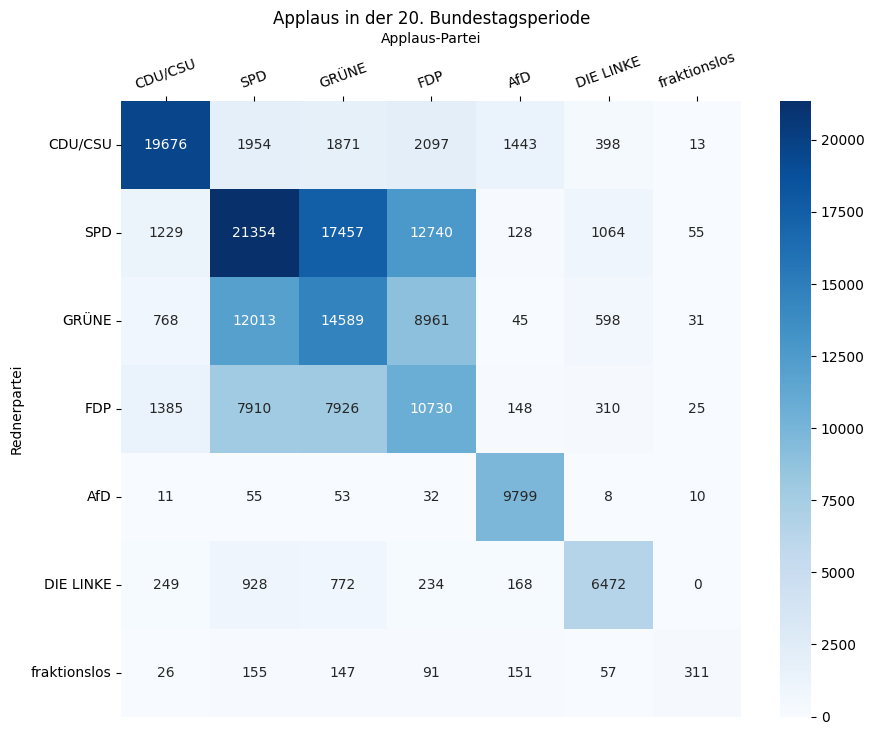

In [19]:
applause_matrix_20 = get_applause_matrix_timespan(bt_period_data['20']['start_date'], bt_period_data['20']['end_date'])

plt.figure(figsize=(10, 8))
plt.title('Applaus in der 20. Bundestagsperiode')

ax = sns.heatmap(applause_matrix_20, annot=True, fmt="d", cmap="Blues",  xticklabels=parties, yticklabels=parties)
ax.set_xticklabels(parties, rotation=20)
ax.set_yticklabels(parties, rotation=0)

ax.set_xlabel('Applaus-Partei', labelpad=5)
ax.set_ylabel('Rednerpartei', labelpad=5)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

Neben der offensichtlichen Diagonale kann man aber auch klar und deutlich die Ampel-Koalition erkennen, die sich untereinander häufig applaudiert.  

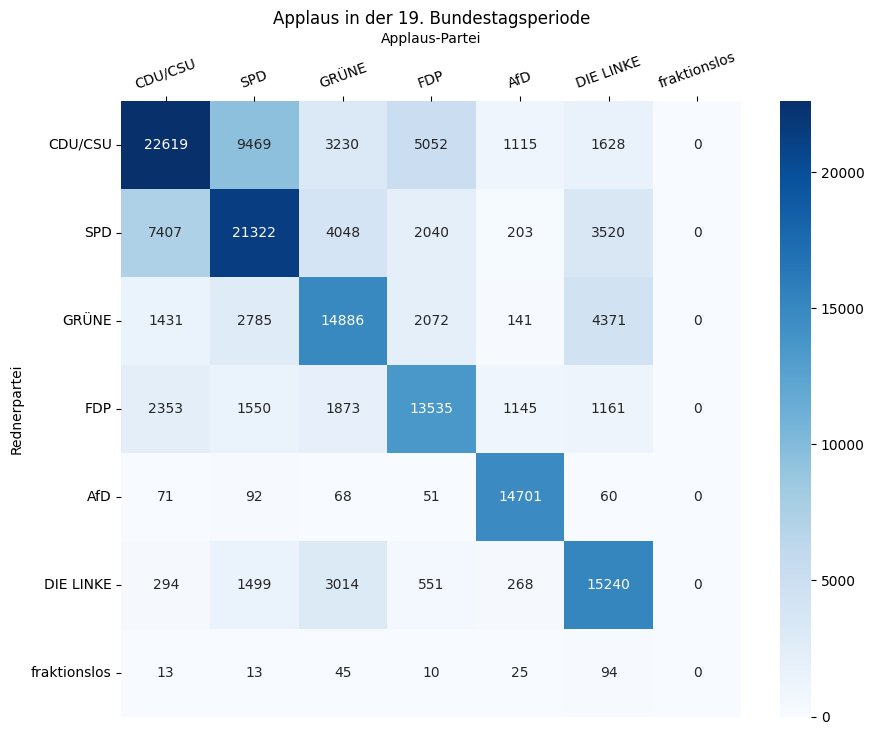

In [20]:
applause_matrix_19 = get_applause_matrix_timespan(bt_period_data['19']['start_date'], bt_period_data['19']['end_date'])

plt.figure(figsize=(10, 8))
plt.title('Applaus in der 19. Bundestagsperiode')

ax = sns.heatmap(applause_matrix_19, annot=True, fmt="d", cmap="Blues",  xticklabels=parties, yticklabels=parties)
ax.set_xticklabels(parties, rotation=20)
ax.set_yticklabels(parties, rotation=0)

ax.set_xlabel('Applaus-Partei', labelpad=5)
ax.set_ylabel('Rednerpartei', labelpad=5)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

Was hier auffällt ist, dass auch die kleineren Parteien sich sehr oft selbst applaudieren. Und das obwohl sie  
1. weniger Sitze im Bundestag haben und  
2. wie oben gezeigt auch weniger Redezeit erhalten, in der sie sich selbst überhaupt applaudieren können

Um 2. näher zu beleuchten, normalisieren wir nach Redezeit (Satzanzahl) der Rednerparteien.

In [21]:
def get_sentences_by_party_timespan(start_date, end_date):
    df_sum_speech_len_sents = df_speeches[(df_speeches['date'] >=start_date) & (df_speeches['date'] <= end_date)]
    df_sum_speech_len_sents = df_sum_speech_len_sents.groupby('speaker_party')['speech_len_sents'].sum().reset_index()
    df_sum_speech_len_sents.columns = ['Party', 'Total_Speech_Length_Sents']
    df_sum_speech_len_sents = df_sum_speech_len_sents.set_index('Party').reindex(parties) # correct order
    return df_sum_speech_len_sents



In [22]:
sents_by_party_19 = get_sentences_by_party_timespan(bt_period_data['19']['start_date'], bt_period_data['19']['end_date'])

print(applause_matrix_19.shape)
print(sents_by_party_19.to_numpy().shape)

applause_matrix_19_norm_sents = applause_matrix_19 / sents_by_party_19.to_numpy() # division by row
applause_matrix_19_norm_sents.shape

(7, 7)
(7, 1)


(7, 7)

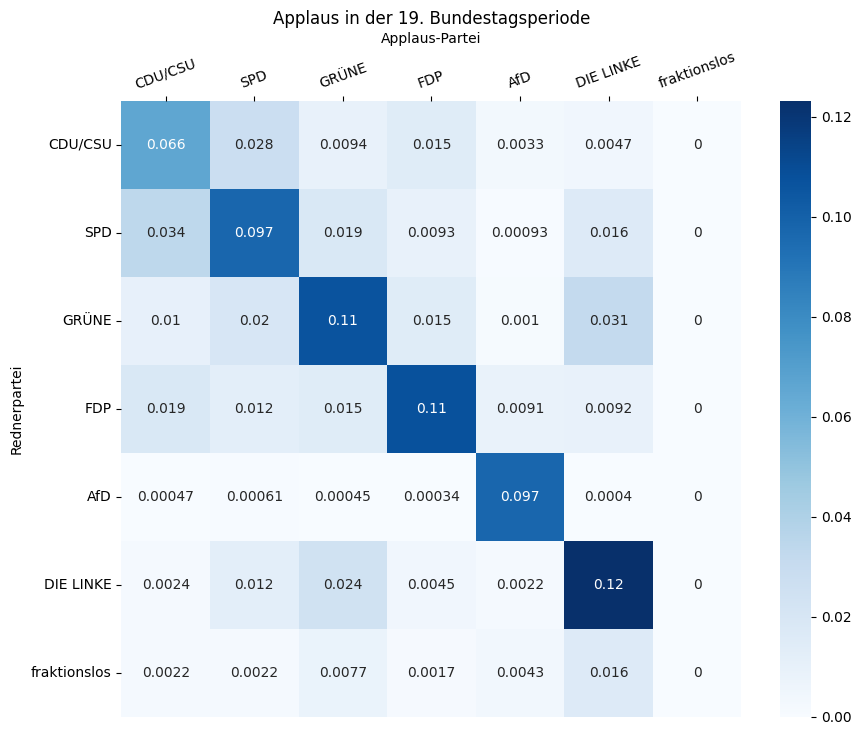

In [23]:
plt.figure(figsize=(10, 8))
plt.title('Applaus in der 19. Bundestagsperiode')

ax = sns.heatmap(applause_matrix_19_norm_sents, annot=True, cmap="Blues",  xticklabels=parties, yticklabels=parties)
ax.set_xticklabels(parties, rotation=20)
ax.set_yticklabels(parties, rotation=0)

ax.set_xlabel('Applaus-Partei', labelpad=5)
ax.set_ylabel('Rednerpartei', labelpad=5)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

Man sieht: Die Linke applaudiert sich selbst pro gesprochenem Satz am öftesten, gefolgt von den Grünen und der FDP.  
Die CDU/CSU fällt mit dem niedrigsten Wert aus dem Raster.

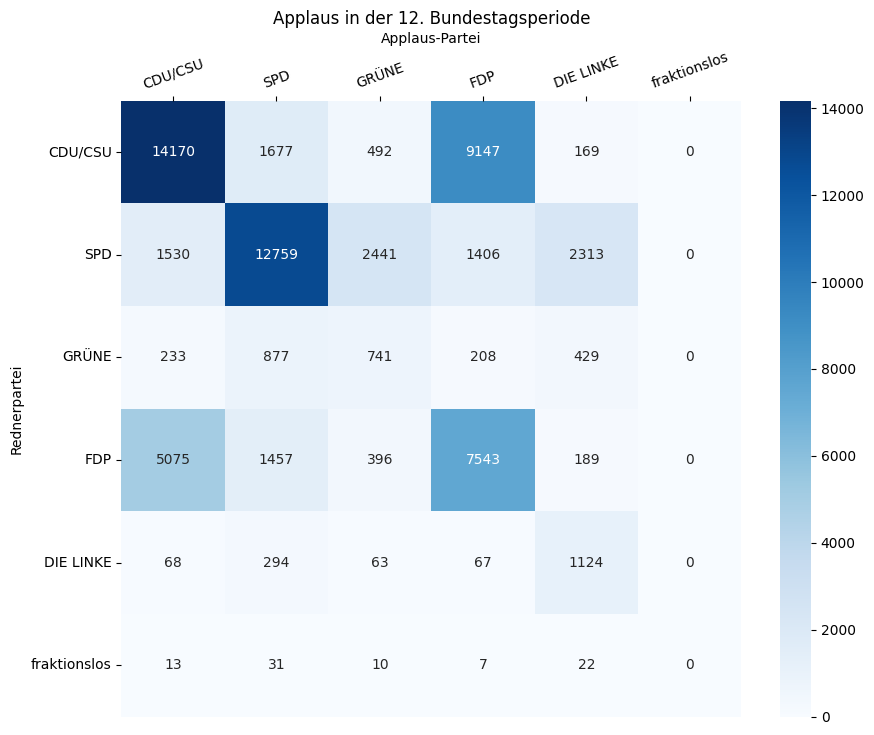

In [24]:
applause_matrix_12 = get_applause_matrix_timespan('1991-03-12', '1994-09-21')

applause_matrix_12 = np.delete(applause_matrix_12, 4, axis=0) # get rid of AfD-values because the party didn't exist yet 
applause_matrix_12 = np.delete(applause_matrix_12, 4, axis=1)

parties_12 = parties.copy()
parties_12.remove('AfD')

plt.figure(figsize=(10, 8))
plt.title('Applaus in der 12. Bundestagsperiode')

ax = sns.heatmap(applause_matrix_12, annot=True, cmap="Blues",fmt="d" , xticklabels=parties_12, yticklabels=parties_12)
ax.set_xticklabels(parties_12, rotation=20)
ax.set_yticklabels(parties_12, rotation=0)

ax.set_xlabel('Applaus-Partei', labelpad=5)
ax.set_ylabel('Rednerpartei', labelpad=5)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

Auffällig ist hier, dass der Plot fast achsensymmetrisch scheint. CDU/cSU und FDP haben sich gegenseitig mehr applaudiert, als den anderen Parteien (außer sich selbst).

In [25]:
sents_by_party_12 = get_sentences_by_party_timespan(bt_period_data['12']['start_date'], bt_period_data['12']['end_date'])

print(applause_matrix_12.shape)
print(sents_by_party_12.to_numpy().shape)
sents_by_party_12 = sents_by_party_12.drop('AfD')

applause_matrix_12_norm_sents = applause_matrix_12 / sents_by_party_12.to_numpy()
applause_matrix_12_norm_sents.shape

(6, 6)
(7, 1)


(6, 6)

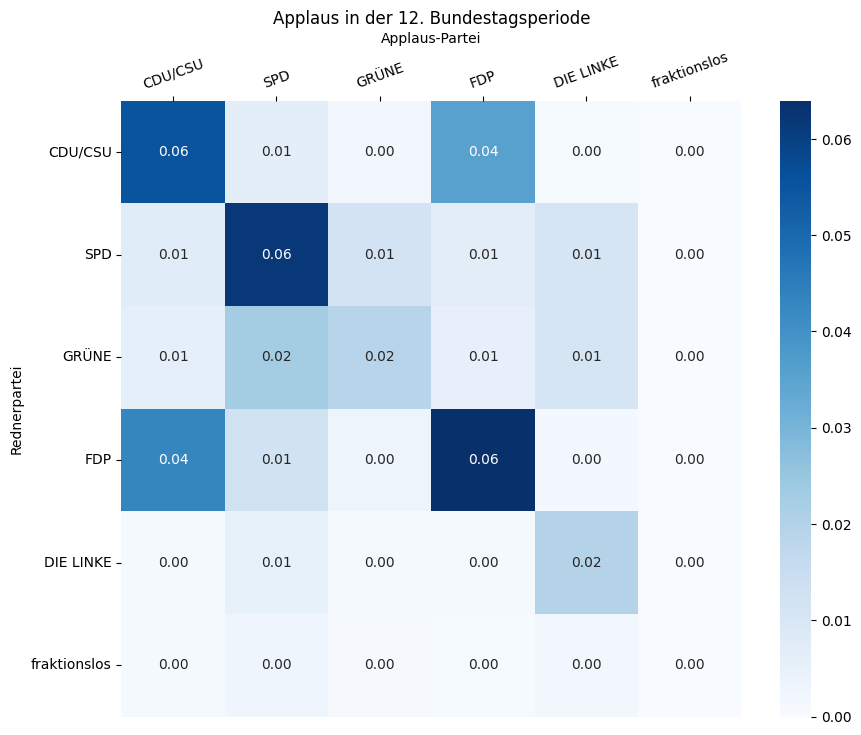

In [26]:
plt.figure(figsize=(10, 8))
plt.title('Applaus in der 12. Bundestagsperiode')

ax = sns.heatmap(applause_matrix_12_norm_sents, annot=True, fmt=".2f", cmap="Blues",  xticklabels=parties_12, yticklabels=parties_12)
ax.set_xticklabels(parties_12, rotation=20)
ax.set_yticklabels(parties_12, rotation=0)

ax.set_xlabel('Applaus-Partei', labelpad=5)
ax.set_ylabel('Rednerpartei', labelpad=5)

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

Im Vergleich mit dem Plot der 19. Bundestagsperiode fällt auf, dass sich die Parteien heutzutage deutlich öfter selbst applaudieren.  
Das könnte aber auch auf unterschiedliche Konventionen bei den Protokollschreibern zurückzuführen sein. Vielleicht liegt mittlerweile der Schwellwert, bei dem Applaus mitnotiert wird auch einfach niedriger.

# Zwischenrufe

Diese Analysen waren für mich der interessanteste Teil des Projekts. Soweit ich weiß, wurden die Zwischenrufe im Bundestag noch nie so abdeckend analysiert.  
Das Einzige, das ich online dazu finden konnte, war [dieses Paper hier](https://shs.hal.science/halshs-01716538/document).  
In diesem Paper ist zwar die Datenqualität etwas besser, da hier alle Zwischenrufe !Manuell Annotiert! wurden, aber der Korpus beschränkt sich deswegen auch nur auf 1251 Zwischenrufe. Zum Vergleich: Ich habe über 400 000 Zwischenrufe aus den Protokollen extrahiert.  
Diese Zwischenrufe im Korpus des Papers sind auch nicht aus allen Plenarprotokollen einer Periode o.ä., sondern aus Plenarprotokollen, die zeitlich nah an Sitzungen des europäischen Rates lagen, damit europäische Fragestellungen abgedeckt werden. Dadurch verschwimmen die Analysen, weil nur wenige (einstellig) Protokolle pro Jahr annotiert wurden und diese sich über mehrere Bundestagsperioden mit unterschiedlichen Koalitionen erstrecken.

In [27]:
df_interruptions_by_interruptor = df_interruptions.groupby('comment_name').count().reset_index()
df_interruptions_by_interruptor = df_interruptions_by_interruptor.rename(columns={'Unnamed: 0':'interruption_counts'})[['comment_name', 'interruption_counts']]
#f_interruptions_by_interruptor['interruption_counts'] = pd.to_numeric(df_interruptions_by_interruptor['interruption_counts'])
df_interruptions_by_interruptor.head()

,comment_name,interruption_counts
0,12982 Merz,1
1,15948 Michelbach,1
2,17276 Rexrodt,1
3,1762 Gehb,1
4,18704 von Stetten,1


Alphabetisch sortiert wird klar, dass sich die Protokollfehler auch beim Parsen der Kommentare bemerkbar gemacht haben. Seitenzahlen, Ids von Drucksachen etc. sind hin und wieder zufällig im Fließtext verstreut... 
Ich habe auch einige der fehlerhaft aussehenden Datenpunkte nachgeschlagen, aber immer nur Protokollfehler und keine Parser-Fehler entdeckt.  

In [28]:
df_interruptions[df_interruptions['comment_name'].apply(lambda x: '12982 Merz' in x)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
93051,93051,"Das wissen Sie doch, dass das nicht stimmt!",CDU/CSU,12982 Merz,GRÜNE,Joseph Fischer,2000-11-17,109,61987


### Daten säubern 

Da wir im Notebook get_abgeordneten_data eine Liste von allen Abgeordneten des Bundestags gesammelt haben, können wir diese Liste jetzt nutzen, um fehlerhafte Daten für die Analyse nach Personen herauszufiltern.  
Dafür laden wir die Liste erst einmal in ein Pandas Dataframe und wechseln die CDU und CSU mit CDU/CSU aus.

In [29]:
abgeordneten_data = pd.read_csv('../_data/abgeordnete.csv')
abgeordneten_data['party'] = abgeordneten_data['party'].apply(lambda p: p if p!= 'CSU' and p!= 'CDU' else 'CDU/CSU')
abgeordneten_data

,name,party,BT-Period
0,Gregor Gysi,DIE LINKE,20
1,Hubert Hüppe,CDU/CSU,20
2,Wolfgang Kubicki,FDP,20
3,Peter Ramsauer,CDU/CSU,20
4,Wolfgang Schäuble,CDU/CSU,20
...,...,...,...
4512,Konrad Wittmann,WAV,1
4513,Max Wönner,SPD,1
4514,Ernst Woltje,DP,1
4515,Walter Zawadil,FDP,1


In [30]:
abgeordneten_data = abgeordneten_data.drop_duplicates('name', keep='first') # drop duplicates and keep first 
abgeordneten_data

,name,party,BT-Period
0,Gregor Gysi,DIE LINKE,20
1,Hubert Hüppe,CDU/CSU,20
2,Wolfgang Kubicki,FDP,20
3,Peter Ramsauer,CDU/CSU,20
4,Wolfgang Schäuble,CDU/CSU,20
...,...,...,...
4512,Konrad Wittmann,WAV,1
4513,Max Wönner,SPD,1
4514,Ernst Woltje,DP,1
4515,Walter Zawadil,FDP,1


Dann suchen wir für jeden Abgeordneten die letzte Bundestagsperiode, in der er/sie im Bundestag war und die Parteizugehörigkeit heraus.  


In [31]:
def get_bt_period(name):
    if name.startswith('Dr. '):
        name = name[4:]

    row = abgeordneten_data[abgeordneten_data['name']==name]
    if not row.empty:
        return row['BT-Period'].values[0]
    return None

def get_party(name):
    if name.startswith('Dr. '):
        name = name[4:]
    row = abgeordneten_data[abgeordneten_data['name']==name]
    if not row.empty:
        return row['party'].values[0]
    return None

get_bt_period('Dr. Angela Merkel')

19

In [32]:
df_interruptions_by_interruptor['bt_period'] = pd.to_numeric(df_interruptions_by_interruptor['comment_name'].apply(get_bt_period), errors='coerce').fillna(-1).astype(int)
df_interruptions_by_interruptor['party'] = df_interruptions_by_interruptor['comment_name'].apply(get_party)
df_interruptions_by_interruptor[:10]

,comment_name,interruption_counts,bt_period,party
0,12982 Merz,1,-1,None
1,15948 Michelbach,1,-1,None
2,17276 Rexrodt,1,-1,None
3,1762 Gehb,1,-1,None
4,18704 von Stetten,1,-1,None
5,21631 Niebel,1,-1,None
6,23806 Schlauch,1,-1,None
7,24628 Homburger,1,-1,None
8,<unknown>,35722,-1,None
9,Achim Groß-mann,3,-1,None


Man sieht: Die fehlerhaften Einträge (und das <unknown> Token\*) haben alle keine Werte zugewiesen bekommen, weil sie nicht in der Liste von Abgeordneten enthalten sind.   
Das können wir zum Filtern nutzen.

\*Das \<unknown\> Token, wird für alle Zurufe gesetzt wird. Erinnerung: Zurufe sind Zwischenrufe, bei der nur die Fraktion, nicht aber der Sprecher, identifiziert werden konnte.

In [33]:
not_found = df_interruptions_by_interruptor[df_interruptions_by_interruptor['party'].map(lambda x: type(x) != str)]
print(len(not_found))
not_found.head(10)

1047


,comment_name,interruption_counts,bt_period,party
0,12982 Merz,1,-1,None
1,15948 Michelbach,1,-1,None
2,17276 Rexrodt,1,-1,None
3,1762 Gehb,1,-1,None
4,18704 von Stetten,1,-1,None
5,21631 Niebel,1,-1,None
6,23806 Schlauch,1,-1,None
7,24628 Homburger,1,-1,None
8,<unknown>,35722,-1,None
9,Achim Groß-mann,3,-1,None


In [34]:
df_interruptions_by_interruptor = df_interruptions_by_interruptor[~df_interruptions_by_interruptor['party'].isna()] # remove all interruptors that are not in our list of BT-Members, this removes protocol errors
#df_interruptions_by_interruptor[-10:] # look at the last 10 entries where errors were previously
df_interruptions_by_interruptor

,comment_name,interruption_counts,bt_period,party
10,Achim Großmann,328,16,SPD
12,Adelheid Tröscher,4,14,SPD
13,Adis Ahmetovic,11,20,SPD
15,Adolf Ostertag,74,14,SPD
16,Agnes Alpers,46,18,DIE LINKE
...,...,...,...,...
2935,Yvonne Magwas,9,20,CDU/CSU
2936,Yvonne Ploetz,2,17,DIE LINKE
2937,Zaklin Nastic,73,20,BSW
2939,Zoe Mayer,72,20,GRÜNE


Jetzt, da die Daten bessere Qualität haben, können wir uns den personenbezogenen Fragestellungen widmen.

### Welche Abgeordneten haben die meisten Zwischenrufe gesammelt?

In [35]:
df_interruptions_by_interruptor = df_interruptions_by_interruptor.sort_values('interruption_counts', ascending=False)
df_interruptions_by_interruptor.head(10)

,comment_name,interruption_counts,bt_period,party
2110,Matthias W. Birkwald,5736,20,DIE LINKE
1730,Jörg Tauss,5470,16,Plos
2601,Stephan Brandner,5139,20,AfD
678,Dr. Heinrich L. Kolb,4804,17,FDP
2591,Steffen Kampeter,3896,18,CDU/CSU
2812,Volker Kauder,3708,19,CDU/CSU
452,Dirk Niebel,3638,17,FDP
2400,Renate Künast,3590,20,GRÜNE
2146,Michael Grosse-Brömer,3577,20,CDU/CSU
1656,Joachim Poß,3554,18,SPD


Den ersten Platz belegt ist Matthias W. Birkwald von der Linken. Und auf dem zweiten Platz sehen wir Jörg Tauss von der nicht existenten Plos-Partei.  
Hier hat sich auch wieder ein Fehler eingeschlichen. Anscheinend sind die !offiziellen! Stammdaten auch nicht gänzlich korrekt. In den 4000 Daten sind aber nur 25 'Plos'-Einträge vorhanden, also ist es bis auf hier kein all zu großes Problem.  
Als Zusatzinfo: Jörg Tauss war aber Teil der SPD-Fraktion, aber nicht alle Abgeordneten, bei denen 'Plos' vermerkt wurde, waren auch Teil der SPD-Fraktion.

Interessant ist auch, dass Stephan Brandner schon auf Platz 3 ist, obwohl er erst in der 19. Bundestagsperiode mit der AfD in den Bundestag eingezogen ist, also nur 2 Wahlperioden hatte, um die Unterbrechungen zu sammeln.



### Wie sieht es unter den top 100 Unterbrechern aus, die aktuell noch im Bundestag vertreten sind?

In [36]:
df_interruptions_by_interruptor_20 = df_interruptions_by_interruptor[df_interruptions_by_interruptor['bt_period'] == 20].head(100)

In [37]:
party_counts = df_interruptions_by_interruptor_20.groupby('party').size().reset_index()
party_counts.columns

Index(['party', 0], dtype='object')

In [38]:
fig = px.pie(
    party_counts, 
    names='party', 
    values=0, 
    color='party', 
    color_discrete_map=party_colors,
    title='Anteil der Abgeordneten unter den top 100 Unterbrechern nach Partei'
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(
    width=800, 
    height=600 
)
fig.show()

Von den Top 100 Unterbrechern, die aktuell im Bundestag sitzen, sind 35 von der CDU/CSU. Die ist ja auch lange die größte Fraktion gewesen.  
Der zweite Platz wird aber nicht von der aktuell stärksten Kraft - der SPD - belegt, sondern von den Grünen.  
Dass die Grünen vor ihrer Zeit in der Regierung auch etwas lauter waren, als heutzutage, kommt in einem der späteren Plots noch zum Vorschein.

### Rufen alle Abgeordneten ungefähr gleich oft hinein?

Jetzt wissen wir, aus welchen Parteien die Top-Unterbrecher sind. Wie sieht es aber insgesamt aus? Unterbrechen alle Abgeordneten ungefähr gleich oft? 

In [39]:
# sort data by interruption counts in descending order
df_pareto = df_interruptions_by_interruptor.reset_index()
df_pareto.iloc[:10]

,index,comment_name,interruption_counts,bt_period,party
0,2110,Matthias W. Birkwald,5736,20,DIE LINKE
1,1730,Jörg Tauss,5470,16,Plos
2,2601,Stephan Brandner,5139,20,AfD
3,678,Dr. Heinrich L. Kolb,4804,17,FDP
4,2591,Steffen Kampeter,3896,18,CDU/CSU
5,2812,Volker Kauder,3708,19,CDU/CSU
6,452,Dirk Niebel,3638,17,FDP
7,2400,Renate Künast,3590,20,GRÜNE
8,2146,Michael Grosse-Brömer,3577,20,CDU/CSU
9,1656,Joachim Poß,3554,18,SPD


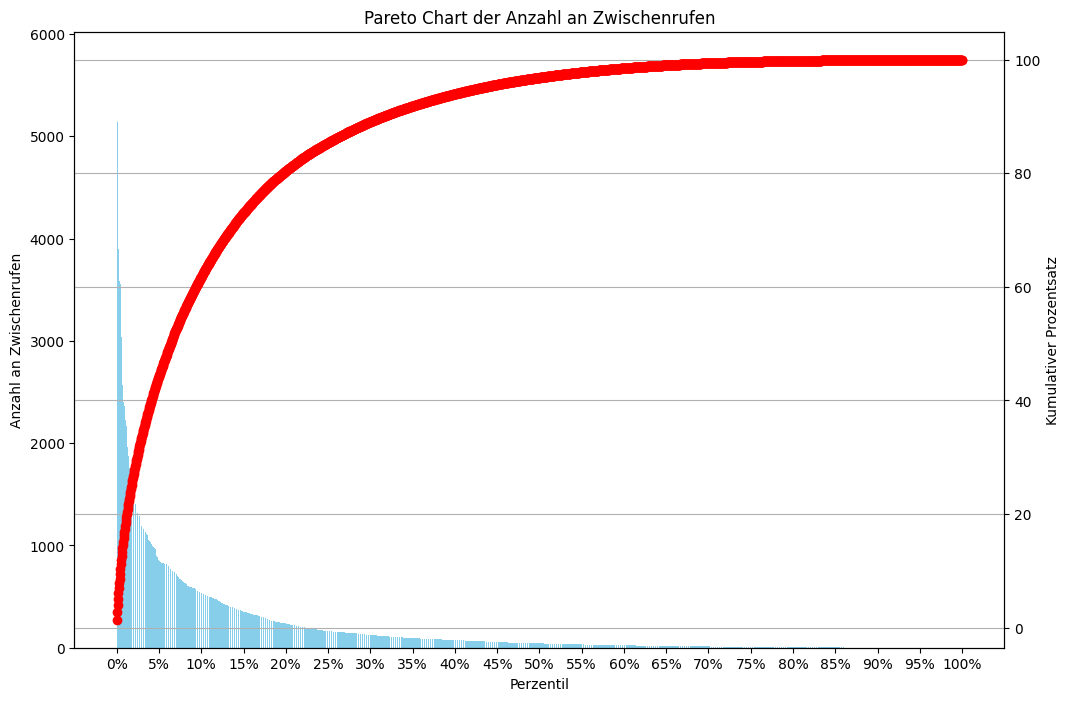

In [40]:
df_pareto = df_pareto.sort_values(by='interruption_counts', ascending=False).reset_index(drop=True)

df_pareto['cum_percentage'] = df_pareto['interruption_counts'].cumsum() / df_pareto['interruption_counts'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(df_pareto.index, df_pareto['interruption_counts'], color='skyblue')
ax1.set_xlabel('Perzentil')
ax1.set_ylabel('Anzahl an Zwischenrufen')

ax2 = ax1.twinx()
ax2.plot(df_pareto.index, df_pareto['cum_percentage'], color='red', marker='o', linestyle='-', linewidth=2)
ax2.set_ylabel('Kumulativer Prozentsatz')

percentiles = range(0, 101, 5)
ax1.set_xticks([len(df_pareto) * p // 100 for p in percentiles])
ax1.set_xticklabels([f'{p}%' for p in percentiles])

plt.title('Pareto Chart der Anzahl an Zwischenrufen')
plt.grid(True)
plt.show()

Die Grafik zeigt, dass ein kleiner Teil der Abgeordneten für den Großteil der Zwischenrufe verantwortlich ist.  
80 Prozent der Zwischenrufe sind auf 20 Prozent der Abgeordneten zurückzuführen.  
Man muss dabei auch im Hinterkopf behalten, dass Abgeordnete, die nie einen Zwischenruf gemacht haben in diesen Daten auch nicht vorhanden sind. Das echte Verhältnis ist also noch unausgeglichener. 

## Anzahl der Zwischenrufe im Zeitverlauf

In [41]:
df_interruptions.columns

Index(['Unnamed: 0', 'comment_text', 'comment_party', 'comment_name',
       'interrupted_speaker_party', 'interrupted_speaker', 'date',
       'speech_len_sents', 'speech_id'],
      dtype='object')

In [42]:
df_interruptions['date'] = pd.to_datetime(df_interruptions['date'])
df_interruptions['year'] = df_interruptions['date'].dt.year

# group by year and calculate the size
interruptions_per_year = df_interruptions.groupby('year').size().reset_index(name='interruptions')

interruptions_per_year.head(5)

,year,interruptions
0,1991,8147
1,1992,8962
2,1993,10587
3,1994,6918
4,1995,9383


In [43]:
fig = px.line(interruptions_per_year,
              x='year',
              y='interruptions',
              title='Zwischenrufe pro Jahr',
              labels={'year': 'Jahr', 'interruptions': 'Anzahl an Zwischenrufen'},
              markers=True)

fig.update_layout(hovermode='x unified')
fig.show()

Durch diese Grafik wird klar, dass sich die Anzahl an Zwischenrufen seit 1991 drastisch erhöht hat. Der höchste Wert aus der Wahlperiode 1990-1994 war knapp über 10 Tausend. In der aktuellen Wahlperiode wurden schon mehr als 3-mal so viele Zwischenrufe abgesetzt.  
Auch zeigt die Grafik, dass die Anzahl an Unterbrechungen stark von Wahlperiode zu Wahlperiode schwankt. Von 2013 bis 2017 gab es zum Beispiel wieder eine relativ ruhige Wahlperiode, während die Wahlperioden davor und danach deutlich unruhiger waren.

Jetzt kommt aber ein noch interessanterer Plot. Der beantwortet die Frage:  

### Wer ist denn für die Zwischenrufe verantwortlich?

In [44]:
# group by year and party and calculate the size
interruptions_per_year_parties = df_interruptions.groupby(['year', 'comment_party']).size().unstack(fill_value=0)
interruptions_per_year_parties

# format for plotly
interruptions_per_year_parties = interruptions_per_year_parties.reset_index().melt(id_vars='year', var_name='comment_party', value_name='interruptions')
interruptions_per_year_parties.to_csv('C:/Users/Robin/Desktop/abc.csv')

In [45]:
fig = px.line(interruptions_per_year_parties,
              x='year',
              y='interruptions',
              color='comment_party',
              title='Zwischenrufe pro Jahr pro Partei',
              labels={'year': 'Jahr', 'interruptions': 'Anzahl an Zwischenrufen', 'comment_party': 'Partei'},
              markers=True,
              color_discrete_map=party_colors)

fig.update_layout(hovermode='x unified')

fig.show()

In diesem Plot stecken viel mehr Informationen, als ich hier sinnvoll schreiben könnte. Deswegen nur ein paar besonders auffällige Punkte:
1. Besonders CDU/CSU fallen in der aktuellen Bundestagsperiode durch viele Zwischenrufe auf. Der Grund liegt vermutlich im Wechsel von Regierung zu Opposition.
2. Die AfD war in allen Wahlperioden, in denen Sie im Bundestag vertreten war, sehr laut.
3. Die Grünen waren in der Wahlperiode von 2013 bis 2017 die lauteste Partei.
4. In den 0er-Jahren bis 2004 gab es schon einmal starkes Wachstum der Anzahl von Zwischenrufen. Vor allem SPD und CDU/CSU waren hier an der Spitze. Die Höchstwerte sind aber nicht mit den Werten der aktuellen Bundestagsperiode zu vergleichen. 
5. In der 19. Bundestagsperiode von 2017 bis 2021 ähneln sich die Anzahlen von Unterbrechungen von allen Parteien stark. Zumindest ist keine so starke Kluft vorhanden, wie aktuell, oder davor.


# Zwischenrufe pro Wahlperiode

Im Folgenden wird immer wieder nach unterschiedlichen Metriken normalisiert.  
Da es der Lesbarkeit schaden würde immer alle Varianten zu plotten, verweise ich hier noch einmal ausdrücklich auf meinen Huggingface-Space.  
https://huggingface.co/spaces/stellamo/bundestag_stats

In [46]:
def get_interruption_count_for_timespan(start_date, end_date):
    relevant_comments = df_interruptions[ (df_interruptions['date'] >=start_date) & (df_interruptions['date']  <= end_date)]
    
    custom_order = parties

    num_interruptions = relevant_comments.groupby('comment_party').size().reset_index(name='num_of_interruptions')

    # reorder rows
    num_interruptions = num_interruptions.set_index('comment_party').reindex(custom_order)

    return num_interruptions

In [47]:
start_date, end_date = bt_period_data['20']['start_date'], bt_period_data['20']['end_date']
df_interruptions_num = get_interruption_count_for_timespan(start_date, end_date)
df_interruptions_num

,num_of_interruptions
comment_party,
CDU/CSU,25664
SPD,10556
GRÜNE,12080
FDP,6176
AfD,17686
DIE LINKE,2868
fraktionslos,31


In [48]:
def plot_interruption_numbers_per_party(df_interruptions_num, norm=False):

    # party names + interrupt counts
    parties = df_interruptions_num.index
    comments_per_party = df_interruptions_num['num_of_interruptions']
    
    party_colors = { # AfD has different color (compared to the line plots). Looks nicer in Block form with light blue background this way
        'CDU/CSU': 'black',
        'SPD': 'red',
        'GRÜNE': 'green',
        'FDP': 'yellow',
        'AfD': 'blue',
        'DIE LINKE': '#bd3075',
        'BSW': '#7d254f',
        'fraktionslos': 'gray'
    }

    # colors...
    fig = go.Figure(data=[go.Bar(x=parties, y=comments_per_party, marker_color=[party_colors[party] for party in parties])])


    yaxis = dict(autorange=True)
    title = 'Number of Interruptions by Party'
    if not norm:
        yaxis['title'] = 'Number of Interruptions'
    else:
        title = 'Number of Interruptions normalized by Party Seats'
        yaxis['title'] = 'Number of Interruptions per Member of Parliament'

    fig.update_layout(title=title,
                      xaxis_title="Party",
                      xaxis=dict(tickangle=-45),
                      yaxis=yaxis
                      )

    fig.show()
plot_interruption_numbers_per_party(df_interruptions_num)

Im 20. Bundestag gab es zum Zeitpunkt dieser Daten 170 Sitzungen.  
    - Das macht für z.B. die Union 24241/170 = 142 Unterbrechungen/Sitzung.  
    - Bei der AfD sind es 16713/170 = 98 Unterbrechungen/Sitzung.   
Ich finde das ist schon ziemlich viel.

Absolute Zahlen sind zwar schön, erzählen aber nicht die ganze Geschichte. In der Linken Fraktion sitzen ja deutlich weniger Abgeordnete, als in der Union.

In [49]:
def get_num_seats_for_period(bt_period):
    num_seats_dict_sorted =  dict(sorted(bt_period_data[str(bt_period)]['num_seats'].items(), key = lambda x: parties.index(x[0])))
    abgeordnete_absolute_nums = [seats for party, seats in num_seats_dict_sorted.items()]
    return abgeordnete_absolute_nums[:-1] # without fraktionslos



In [50]:
abgeordnete_absolute_nums = get_num_seats_for_period('20')
df_interruptions_num_norm_seats = df_interruptions_num.drop(index='fraktionslos').div(abgeordnete_absolute_nums, axis=0)
df_interruptions_num_norm_seats['num_of_interruptions'] = df_interruptions_num_norm_seats['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats, norm=True)

Hier zeigt sich noch eine deutlichere Kluft. Im Schnitt hat jeder Abgeordnete der AfD alleine in dieser Wahlperiode schon über 220 mal hineingerufen. Das ist über 4-mal so viel, wie bei den Abgeordneten der SPD.

# Wer ruft wem überhaupt rein?

Die folgenden Pandas-Kommandos errechnen aus unserem interruption-dataframe eine quadratische Matrix, in der die Unterbrechungen aufgeschlüsselt sind. Das Ganze ist mit start- und Enddatum einschränkbar.  
Zusätzlich wird berechnet, wie viele Sätze die Redner-Partei im gegebenen Zeitraum gesprochen hat. Damit können wir dann auch nach Redeanteil normalisieren.  

Anmerkung: Plots kommen nicht direkt, damit sie näher aneinander sein können und man für Vergleiche nicht so viel scrollen muss.

In [51]:
def get_interrupt_matrix_for_timespan(start_date, end_date):
    relevant_comments = df_interruptions[ (df_interruptions['date'] >=start_date) & (df_interruptions['date']  <= end_date)]

    interruption_matrix = pd.crosstab(relevant_comments['comment_party'], relevant_comments['interrupted_speaker_party']) # pretty handy function...

    interruption_matrix = interruption_matrix.reindex(parties, axis=1)
    interruption_matrix = interruption_matrix.reindex(parties, axis=0)

    return interruption_matrix.T

start_date, end_date = bt_period_data['20']['start_date'], bt_period_data['20']['end_date']
interruption_matrix = get_interrupt_matrix_for_timespan(start_date, end_date)

interruption_matrix

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,3099,5330,6625,3208,2817,720,1
SPD,9411,893,631,446,6223,498,5
GRÜNE,6407,354,593,249,4125,298,7
FDP,4605,363,375,451,2367,474,2
AfD,942,2988,3156,1047,969,454,3
DIE LINKE,1061,437,485,683,1104,409,0
fraktionslos,139,191,215,92,81,15,13


Normalisieren mit gesprochenen Sätzen der Redner-Parteien

In [52]:
def get_num_sents_by_party_for_timespan(start_date, end_date):
    relevant_speeches = df_speeches[(df_speeches['date'] >= start_date) &(df_speeches['date'] <= end_date)]
    out = relevant_speeches.groupby('speaker_party')['speech_len_sents'].sum().reset_index()
    out.columns = ['Party', 'Total_Speech_Length_Sents']
    out = out.set_index('Party').reindex(parties)
    return out

sentence_counts = get_num_sents_by_party_for_timespan(start_date, end_date)
sentence_counts

,Total_Speech_Length_Sents
Party,
CDU/CSU,224117
SPD,224119
GRÜNE,134034
FDP,111719
AfD,99873
DIE LINKE,60259
fraktionslos,9450


Normalisieren bedeutet hier elementweises dividieren der Spalten mit dem Vektor.

In [53]:
interruption_matrix_norm_sents = interruption_matrix.div(np.array(sentence_counts)) 
interruption_matrix_norm_sents

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE,fraktionslos
interrupted_speaker_party,,,,,,,
CDU/CSU,0.013828,0.023782,0.029560,0.014314,0.012569,0.003213,0.000004
SPD,0.041991,0.003984,0.002815,0.001990,0.027766,0.002222,0.000022
GRÜNE,0.047801,0.002641,0.004424,0.001858,0.030776,0.002223,0.000052
FDP,0.041219,0.003249,0.003357,0.004037,0.021187,0.004243,0.000018
AfD,0.009432,0.029918,0.031600,0.010483,0.009702,0.004546,0.000030
DIE LINKE,0.017607,0.007252,0.008049,0.011334,0.018321,0.006787,0.000000
fraktionslos,0.014709,0.020212,0.022751,0.009735,0.008571,0.001587,0.001376



Das zeigt immer noch nicht das ganze Bild. Schließlich gibt es in der CDU/CSU-Fraktion im Vergleich mit der AfD-Fraktion mehr als doppelt so viele Abgeordnete. Also normalisieren wir nach der Anzahl der Sitze. Die Prozentsätze der Zweitstimmen finden sich hier.

Normalisieren nach der Anzahl der Sitze bedeutet, die Spalten durch den Stimmenanteil zu teilen -> geringerer Stimmenanteil -> Score wird höher. Leider verlieren wir etwas an Interpretierbarkeit, weil es nicht mehr nur einfache Unterbrechungen pro Satz sind und die resultierende Einheit (Unterbrechungen/Satz)/Sitz nicht sehr intuitiv ist.

Anmerkung: Der Einfachheit halber lassen wir fraktionslose Abgeordnete weg. Deren Zahlen sind sowieso sehr niedrig und die Berechnungen der nächsten Abschnitte wären unnötig kompliziert, wenn man diese mitschleifen müsste

In [54]:
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(labels='fraktionslos')
interruption_matrix_norm_sents = interruption_matrix_norm_sents.drop(columns='fraktionslos')

interruption_matrix_norm_sents_seats = interruption_matrix_norm_sents.div(abgeordnete_absolute_nums, axis=1)
interruption_matrix_norm_sents_seats

comment_party,CDU/CSU,SPD,GRÜNE,FDP,AfD,DIE LINKE
interrupted_speaker_party,,,,,,
CDU/CSU,0.000071,0.000115,0.000251,0.000157,0.000163,0.000115
SPD,0.000215,0.000019,0.000024,0.000022,0.000361,0.000079
GRÜNE,0.000245,0.000013,0.000037,0.000020,0.000400,0.000079
FDP,0.000211,0.000016,0.000028,0.000044,0.000275,0.000152
AfD,0.000048,0.000145,0.000268,0.000115,0.000126,0.000162
DIE LINKE,0.000090,0.000035,0.000068,0.000125,0.000238,0.000242


## Plotten

Jetzt, da die Werte vergleichbar sind, haben sie auch einen schönen Plot verdient.  
Der wurde von oben aufgespart, damit man die Plots ohne viel Scrollen nah beieinander hat.  
Reihenfolge:
- Nicht normalisiert
- normalisiert nach Redeanteil (Anzahl Sätze)
- normalisiert nach Sitzen
- normalisiert nach Sitzen und Redeanteil.

In [55]:
def plot_interruption_matrix(interruption_matrix):
    plt.figure(figsize=(8,7))
    sns.set_style("whitegrid")

    ax = sns.heatmap(interruption_matrix, cmap="Blues", annot=False, cbar=True, square=True, cbar_kws={'shrink': 0.8})

    # Rotate x-axis labels
    if len(interruption_matrix.columns) < len(parties): # ohne Fraktionslose Abgeordnete
        ax.set_xticklabels(parties[:-1], rotation=20)
        # Rotate x-axis labels
        ax.set_yticklabels(parties[:-1], rotation=0)
    else:
        ax.set_xticklabels(parties, rotation=20)
        ax.set_yticklabels(parties, rotation=0)

    # Set y-axis labels to the top
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')

    ax.set_xlabel('Zwischenruf-Partei', labelpad=5)
    ax.set_ylabel('Rednerpartei', labelpad=5)

    plt.title('Unterbrechungen im Bundestag', pad=20)
    plt.show()


#### Absolute Zahlen:

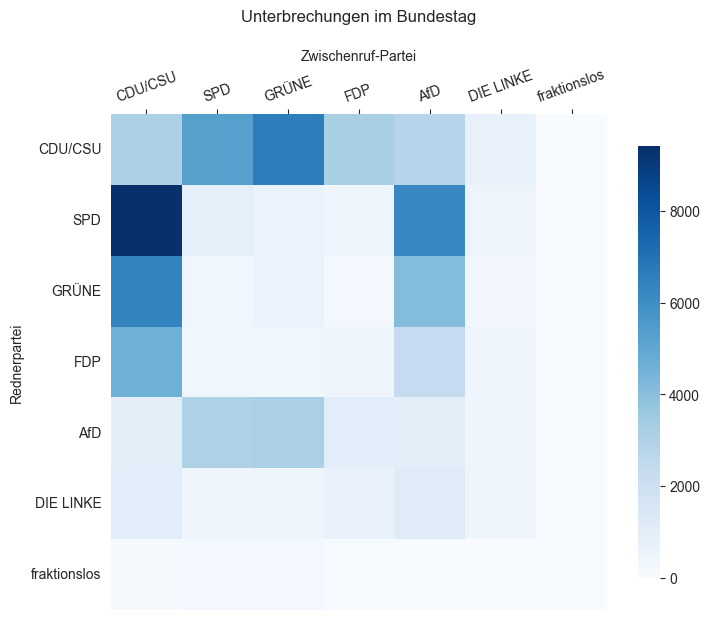

In [56]:
plot_interruption_matrix(interruption_matrix)

In absoluten Zahlen erkennt man, dass die Ampel-Parteien vor allem von CDU/CSU und von der AfD unterbrochen werden.  
Der Plot ist fast schon ein Inverses des obigen Plots zum Beifall. So wie man dort den Beifall unter den Ampel-Parteien gesehen hat, so sieht man hier ein weißes Viereck, in dem eben nicht dazwischengerufen wird. 

#### Normalisiert nach Anzahl der insgesamt gesprochenen Sätze der Redner-Partei

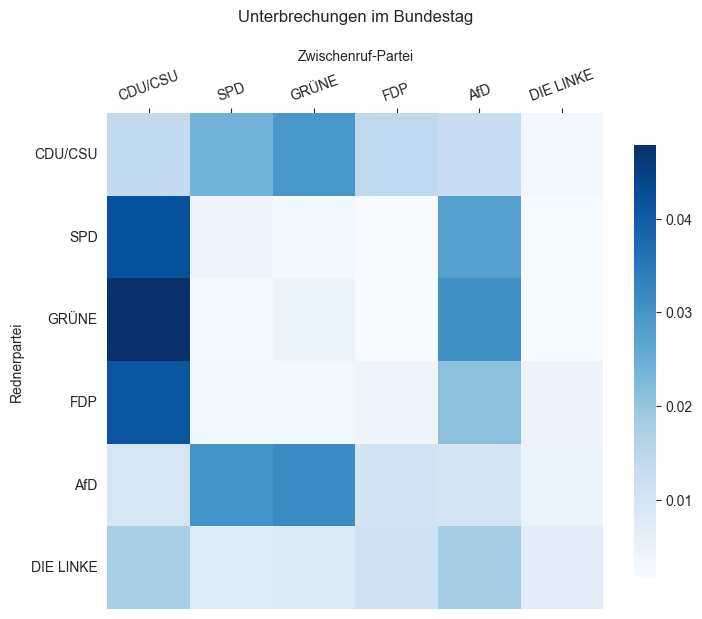

In [57]:
plot_interruption_matrix(interruption_matrix_norm_sents)

Die Grundaussage bleibt gleich - Koalitionsparteien unterbrechen sich gegenseitig kaum - aber es zeigt sich, dass grüne Redner pro Satz häufiger unterbrochen werden, als deren Kollegen von der FDP und SPD.  
Der Wert bei Zwischenrufen von der CDU/CSU ist bei circa 0.05, was 20 Sätzen/Unterbrechung entspricht. Wenn man bedenkt, dass das auch völlig unproblematische Reden über nicht polarisierende Themen sein können, dann ist das schon nicht unerheblich.

Dabei "wehren" sich SPD und Grüne eigentlich nur bei der AfD.

#### Normalisiert nach Anzahl der Sitze der Unterbrecher-Partei

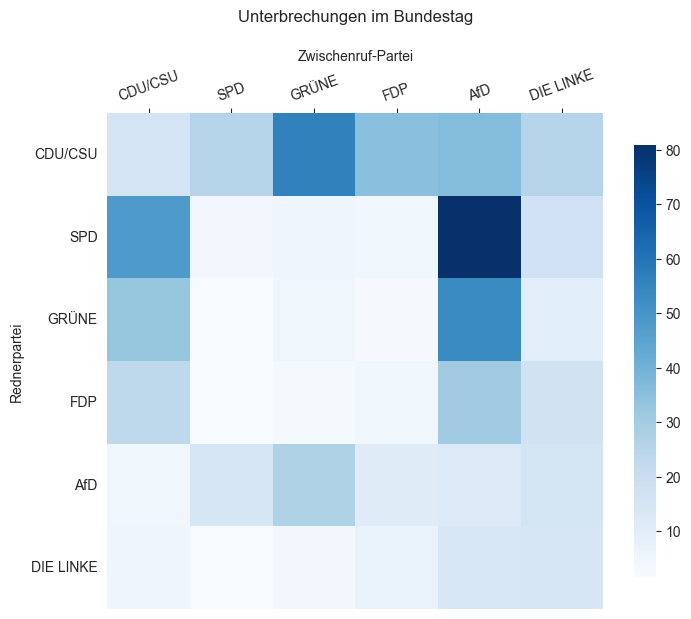

In [58]:
interruption_matrix_norm_seats = interruption_matrix.drop(columns='fraktionslos').drop(index='fraktionslos').div(abgeordnete_absolute_nums, axis=1)
plot_interruption_matrix(interruption_matrix_norm_seats)

Auch hier bleibt die Kernaussage gleich, der Fokus verschiebt sich aber darauf, dass Abgeordnete der AfD besonders oft hineinrufen.  
Bei ihrem Lieblings-Ziel der SPD hat im Schnitt jeder Abgeordnete schon 70 Zwischenrufe getätigt.

#### Normalisiert nach Anzahl der Sätze der Redner-Partei und Anzahl der Sitze der Unterbrecher-Partei

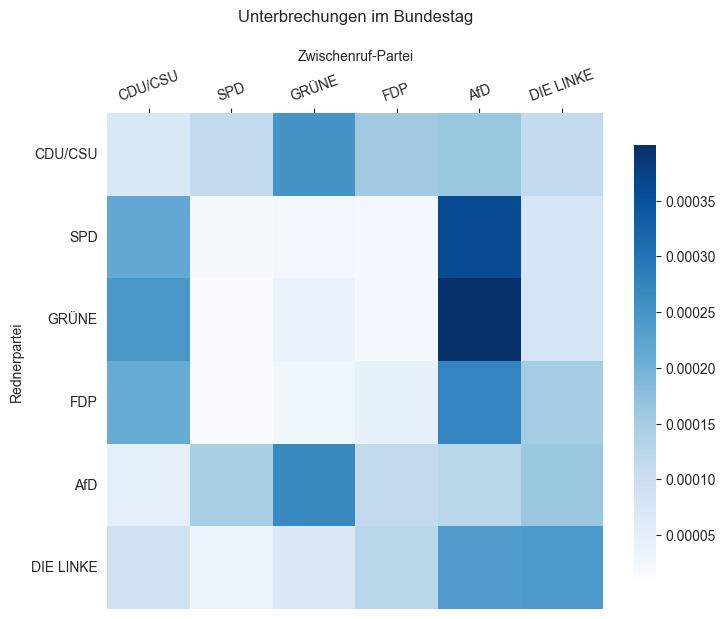

In [59]:
plot_interruption_matrix(interruption_matrix_norm_sents_seats)

Das ist jetzt eine Mischung aus den letzten beiden Plots. Man sieht, dass im Schnitt jeder Abgeordnete der AfD pro Redezeit des Redners besonders oft hineinruft.  
Was vorher noch nicht so sehr herauskam, ist, dass Linke Abgeordnete auch vergleichsweise oft Zwischenrufe tätigen, während ihre eigene Partei vorne steht.  
Das wirft die Frage auf, ob alle Zwischenrufe positiv sind. Eine Frage, die in der Sentiment-Analyse aufgegriffen wird.

Zusammenfassung der Darstellungsformen: Je nach Art der Normalisierung liest man unterschiedliche Dinge heraus. Auch das Interpretieren fällt bei den ersten 3 Plots leichter, als beim letzten.

# Andere Bundestagsperioden  


## 19. Bundestag

In [60]:
start_date_19, end_date_19 = bt_period_data['19']['start_date'], bt_period_data['19']['end_date']
df_interruptions_num_19 = get_interruption_count_for_timespan(start_date_19, end_date_19)
plot_interruption_numbers_per_party(df_interruptions_num_19)

Interessant, oder? Während im 20. Bundestag jetzt schon (über 1 Jahr vor dem Ende) fast 25 Tausend Unterbrechungen von der Union und über 16 Tausend Unterbrechungen von der AfD gemacht wurden, so ist es im 19. Bundestag deutlich ausgeglichener.  
Fast alle Parteien finden sich so um bis etwas über der 10k-Marke.  
Ist der Ton im Bundestag wohl mit dem Ende der GroKo rauer geworden? Vor allem bei den Nicht-Koalitionsfraktionen Union und AfD, hat die Frequenz der Zwischenrufe nochmal stark zugenommen.

In [61]:

abgeordnete_absolute_nums_19 =  get_num_seats_for_period('19')
df_interruptions_num_norm_seats_19 = df_interruptions_num_19.drop(index='fraktionslos').div(np.array(abgeordnete_absolute_nums_19), axis=0)
df_interruptions_num_norm_seats_19['num_of_interruptions'] = df_interruptions_num_norm_seats_19['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_19, norm=True)

Die Union war also nicht schon immer so ein Störenfried. Wenn man selbst an der Regierung beteiligt ist, weicht ja auch weniger von der eigenen Parteilinie ab.  
Was auch hervorsticht, ist, dass DIE LINKE (pro Sitz) in dieser Wahlperiode deutlich öfter dazwischengerufen hat. Der Verlust ihrer Fraktion (Als Fraktion gilt man erst ab 5%) hat ihnen in der 20. Wahlperiode wohl zu schaffen gemacht.

In [62]:
interruption_matrix_19 = get_interrupt_matrix_for_timespan(start_date_19, end_date_19)
sentence_counts_19 = get_num_sents_by_party_for_timespan(start_date_19, end_date_19)

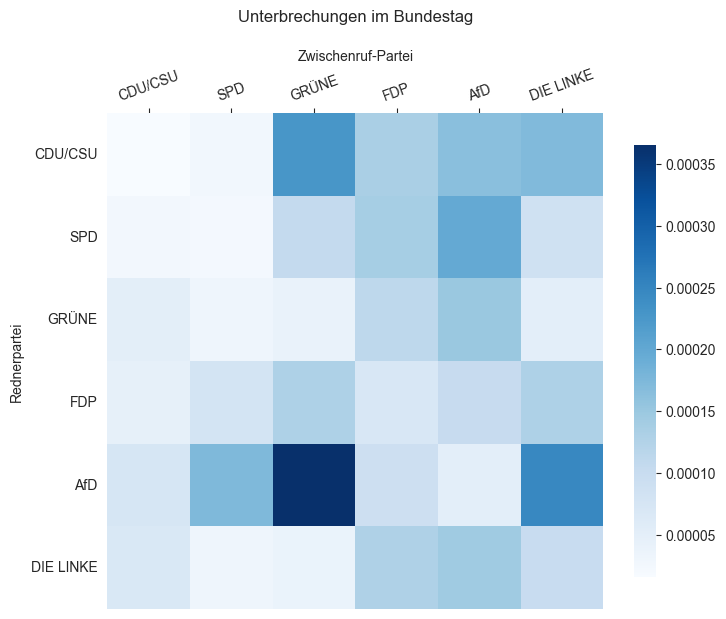

In [63]:
interruption_matrix_norm_sents_19 = interruption_matrix_19.div(np.array(sentence_counts_19))
interruption_matrix_norm_sents_19 = interruption_matrix_norm_sents_19.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_19 = interruption_matrix_norm_sents_19.div(np.array(abgeordnete_absolute_nums_19), axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_19)

In der 19. Bundestagsperiode haben Grüne und SPD versucht der damals neuen AfD durch Zwischenrufe etwas Gegenwind zu geben.
Das relativ helle Viereck in der oberen linken Ecke zeigt den Zusammenhalt innerhalb der GroKo.

## 18. Bundestag

In [64]:
start_date_18, end_date_18 = bt_period_data['18']['start_date'],bt_period_data['18']['end_date']
df_interruptions_num_18 = get_interruption_count_for_timespan(start_date_18, end_date_18)
plot_interruption_numbers_per_party(df_interruptions_num_18)

Nur 4 Parteien. Damals sind AfD und FDP sind mit jeweils weniger als einem halben Prozent am Bundestag vorbeigeschlittert. 
Interessant ist hier auch, dass die Grünen mit nur 8,4 % über 18 Tausend Zwischenrufe haben. 

In [65]:
abgeordnete_absolute_nums_18 = get_num_seats_for_period('18')
df_interruptions_num_norm_seats_18 = df_interruptions_num_18.drop(index='fraktionslos').div(np.array(abgeordnete_absolute_nums_18), axis=0)
df_interruptions_num_norm_seats_18['num_of_interruptions'] = df_interruptions_num_norm_seats_18['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_18, norm=True)

Kompletter Ausreißer sind hier die Grünen fast 300 Zwischenrufen pro Sitz im Bundestag. Das ist schon eine Ansage. Im 18. BT gab es 245 Sitzungen, es ist also im Schnitt jeder Abgeordnete in jeder Sitzung dem Redner mehr als ein mal ins Wort gefallen. Und das ohne, dass man die Abwesenheiten miteinbezieht...

In [66]:
interruption_matrix_18 = get_interrupt_matrix_for_timespan(start_date_18, end_date_18)
sentence_counts_18 = get_sentences_by_party_timespan(start_date_18, end_date_18)
interruption_matrix_18.loc['FDP',:] = float("nan")
interruption_matrix_18.loc[:,'FDP'] = float("nan")
sentence_counts_18.loc['FDP'] = float("nan")
# Sonderfall FDP. In einer der ersten Sitzungen spricht auch die sich damals noch im Amt befindende Staatsministerin im Auswärtigen Amt, Cornelia Pieper (FDP)
# Deswegen bereinigung der FDP-Zeilen + Spalten

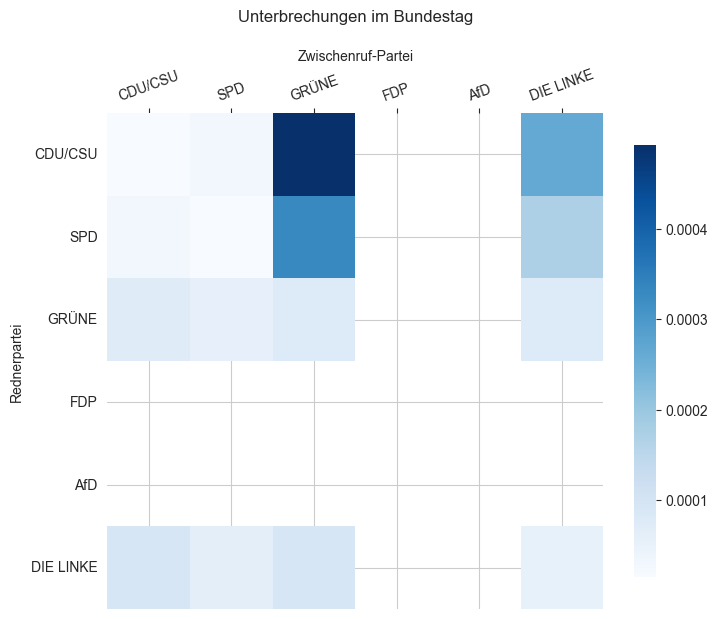

In [67]:
interruption_matrix_norm_sents_18 = interruption_matrix_18.div(np.array(sentence_counts_18))
interruption_matrix_norm_sents_18 = interruption_matrix_norm_sents_18.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_18 = interruption_matrix_norm_sents_18.div(abgeordnete_absolute_nums_18, axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_18)

Grüne und Linke (beide Opposition) haben sich also vorrangig gegen die eher stille GroKo geäußert. 

\*Anmerkung: Hier wurde mit Absicht der Plot gewählt, bei dem AfD und FDP zwar vorhanden, aber nicht mit Werten befüllt sind, damit die Grafiken untereinander leichter vergleichbar bleiben.

### Zeitsprung zu 1991

Kurz nach der Wiedervereinigung. Viele Zwischenrufe gehen gegen die PDS (Nachfolgepartei der SED), welche bald mit der Linken fusioniert. Streitthema ist v.a. das Parteivermögen, das sich auf 6,2 Milliarden DDR-Mark belief und bei der Fusion an die Linken überging.  

Weil leider im März 1991 das Format angepasst wurde, sind die Daten über diese Wahlperiode nicht vollständig. Sie beginnen ab der 15. Sitzung (von insgesamt 243).

In [68]:
start_date_12, end_date_12 = bt_period_data['12']['start_date'], bt_period_data['12']['end_date']
df_interruptions_num_12 = get_interruption_count_for_timespan(start_date_12, end_date_12)
plot_interruption_numbers_per_party(df_interruptions_num_12)

Die Normalisierung nach Sitzen geht hier nicht so schön mit Berechnungen.  
Nach der Wiedervereinigung gab es einige Sonderregelungen. Deswegen eine Liste von [hier](https://de.wikipedia.org/wiki/12._Deutscher_Bundestag)

In [69]:
abgeordnete_absolute_nums_12 = get_num_seats_for_period('12')
df_interruptions_num_norm_seats_12 = df_interruptions_num_12.drop(index='fraktionslos').div(abgeordnete_absolute_nums_12, axis=0)
df_interruptions_num_norm_seats_12['num_of_interruptions'] = df_interruptions_num_norm_seats_12['num_of_interruptions'].round(2)
plot_interruption_numbers_per_party(df_interruptions_num_norm_seats_12, norm=True)

Obwohl hier durch die wenig aussagekräftige Mitgliederanzahl der Grünen und der Linken (PDS) bei der Normalisierung leicht ein verzerrtes Bild hätte aufkommen können, schwanken alle Parteien um die 50+-12 Zurufen/Sitz.  
Das kann Zufall sein, setzt aber die Anzahl an Unterbrechungen/Sitz in der aktuellen BT-Periode in Kontext und zeigt, wie hoch die aktuellen Zahlen im historischen Vergleich sind.

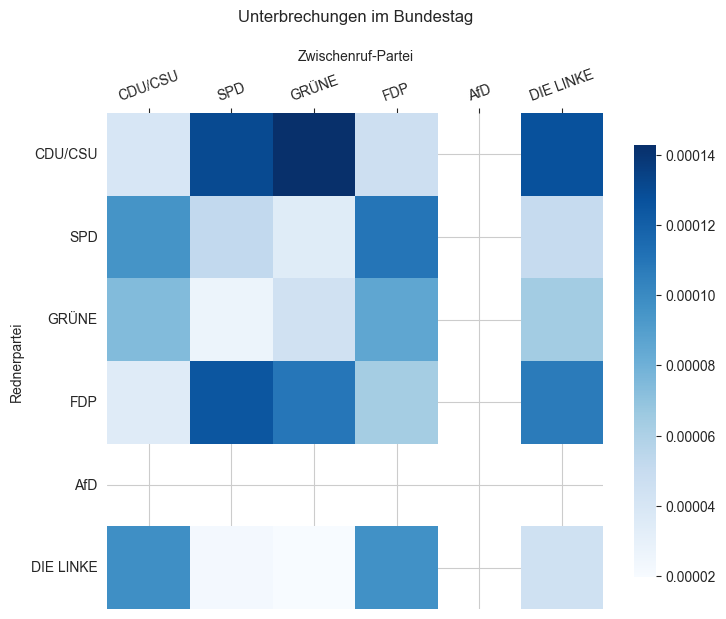

In [70]:
interruption_matrix_12= get_interrupt_matrix_for_timespan(start_date_12, end_date_12)
sentence_counts_12 = get_sentences_by_party_timespan(start_date_12, end_date_12)
interruption_matrix_norm_sents_12 = interruption_matrix_12.div(np.array(sentence_counts_12))
interruption_matrix_norm_sents_12 = interruption_matrix_norm_sents_12.drop(labels='fraktionslos').drop(columns='fraktionslos')
interruption_matrix_norm_sents_seats_12 = interruption_matrix_norm_sents_12.div(abgeordnete_absolute_nums_12, axis=1)
plot_interruption_matrix(interruption_matrix_norm_sents_seats_12)

Eine interessante Aufgabe ist es, aus diesen Plots herauszulesen, wer gerade in der Regierung und wer in der Opposition ist.  

<details>
<summary>Lösung</summary>

**Regierung**: Union und FDP  
**Opposition**: SPD, Grüne, LINKE/PDS  

Erklärung: Normalerweise unterbrechen sich die Parteien, die gemeinsam in der Koalition (oder gemeinsam in der Opposition) sind weniger, als Parteien, die nicht miteinander verbunden sind. Es gibt zwar hin und wieder Unterstützungsrufe aber die Mehrheit der Zwischenrufe ist negativ (siehe Sentimentanalyse).  
Das ergibt zwei Gruppen: Gruppe 1: [CDU/CSU, FDP]; Gruppe 2: [SPD, Grüne, DIE LINKE (PDS)]. Weil die Gruppe 2, etwas öfter die Ursache von Unterbrechungen ist, kann man schlussfolgern, dass diese vermutlich die Opposition darstellt.  

</details>

# Fazit

Das war die statistische Analyse der Anzahl von Sätzen und Zwischenrufen.

### Erkenntnisse

* Die letzten beiden Wahlperioden sind besonders von Unterbrechungen geprägt. Seit die AfD im Bundestag vertreten ist, gehört sie zu den Top-Unterbrechern. Außerdem hat die Union seit sie in der Opposition ist, einen lauteren Ton an den Tag gelegt.
* Opposition und Koalition unterbrechen sich oft gegenseitig. Koalitionsparteien unterbrechen sich untereinander aber kaum -> Unterbrechungen scheinen eher negativ zu sein (Ergebnisse der Sentimentanalyse folgen in späteren Notebooks)

Obwohl das schon viele Plots waren, kann ich hier nur wieder auf den [Huggingface-Space](https://huggingface.co/spaces/stellamo/bundestag_stats) verweisen. Wenn man selbst mit den Normalisierungsarten herumspielen kann, gewinnt man schneller ein Gefühl für die Daten.
